# Assignment 8: High Frequency Words
### DATA 620
### Miraj Patel

In [3]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from nltk.corpus import reuters
from nltk.stem import WordNetLemmatizer
from collections import Counter

# Download required NLTK resources 
# 'reuters' is our corpus of interest. 
# 'punkt' is for tokenization.
# 'wordnet' and 'omw' are for Lemmatization.
nltk.download('reuters')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw')

# Load raw words from the Reuters corpus
raw_words = reuters.words()
print(f"Total raw tokens in corpus: {len(raw_words)}")

[nltk_data] Downloading package reuters to
[nltk_data]     C:\Users\Miraj\AppData\Roaming\nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Miraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Miraj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw to
[nltk_data]     C:\Users\Miraj\AppData\Roaming\nltk_data...


Total raw tokens in corpus: 1720901


## Data Background

For this assignment, I have chosen the Reuters-21578 Corpus, a standard benchmark in Natural Language Processing. This dataset consists of 10,788 news documents toaling over 1.7 million raw tokens. I chose this corpus for few reasons. First, with nearly 2 million tokens, the corpus provides a sufficinetly large sample size to accurately test Zipf's Law. Second, the vocabulary is standardized as  news reporting follows strict editorial guidelines. Lastly, the corpus contains an unique mix of general English stop-words and industry specific terminology, allowing for a more nuanced comparison to "all words in all corpora".

In [4]:
# Initialize the Lemmatizer for linguistic normalization
lemmatizer = WordNetLemmatizer()

# Defining Unique Words Criteria: 
# 1. Case Normalization: Lowercase all words to treat 'The' and 'the' as the same.
# 2. Noise Removal: Use .isalpha() to strip numbers and punctuation.
# 3. Lemmatization: Group semantic roots (e.g., 'profits' and 'profit') into one unique word.
cleaned_words = [
    lemmatizer.lemmatize(w.lower()) 
    for w in raw_words 
    if w.isalpha()
]

# Calculate the vocabulary metrics
total_cleaned_count = len(cleaned_words)
unique_word_count = len(set(cleaned_words))

print(f"Total Words (after cleaning): {total_cleaned_count}")
print(f"Total Unique Words (Vocabulary): {unique_word_count}")

Total Words (after cleaning): 1327141
Total Unique Words (Vocabulary): 26742


In [5]:
# Create a frequency distribution of our cleaned words
counts = Counter(cleaned_words)
most_common_sorted = counts.most_common()

# Calculate the target (50% of the total cleaned word count)
half_total_threshold = total_cleaned_count / 2
running_sum = 0
unique_word_tally = 0

# Iterate through sorted words until we hit the 50% mark
for word, frequency in most_common_sorted:
    running_sum += frequency
    unique_word_tally += 1
    if running_sum >= half_total_threshold:
        break

print(f"Total Words in Corpus: {total_cleaned_count}")
print(f"50% Threshold: {half_total_threshold}")
print(f"Number of unique words representing half of the corpus: {unique_word_tally}")
print(f"Percentage of total vocabulary: {(unique_word_tally / unique_word_count) * 100:.4f}%")

Total Words in Corpus: 1327141
50% Threshold: 663570.5
Number of unique words representing half of the corpus: 96
Percentage of total vocabulary: 0.3590%


The results of this calculation reveals a remarkably small number of unique words account for the vast majority of the text. In the Reuters corpus, it takes only 96 unique words to represent 50% of the 1,327,141 total words. This core group represents only 0.3590% of the total unique vocabulary (26,742 words). This concentration is primarily driven by function words such as prepositions, determiners, and conjunctions.


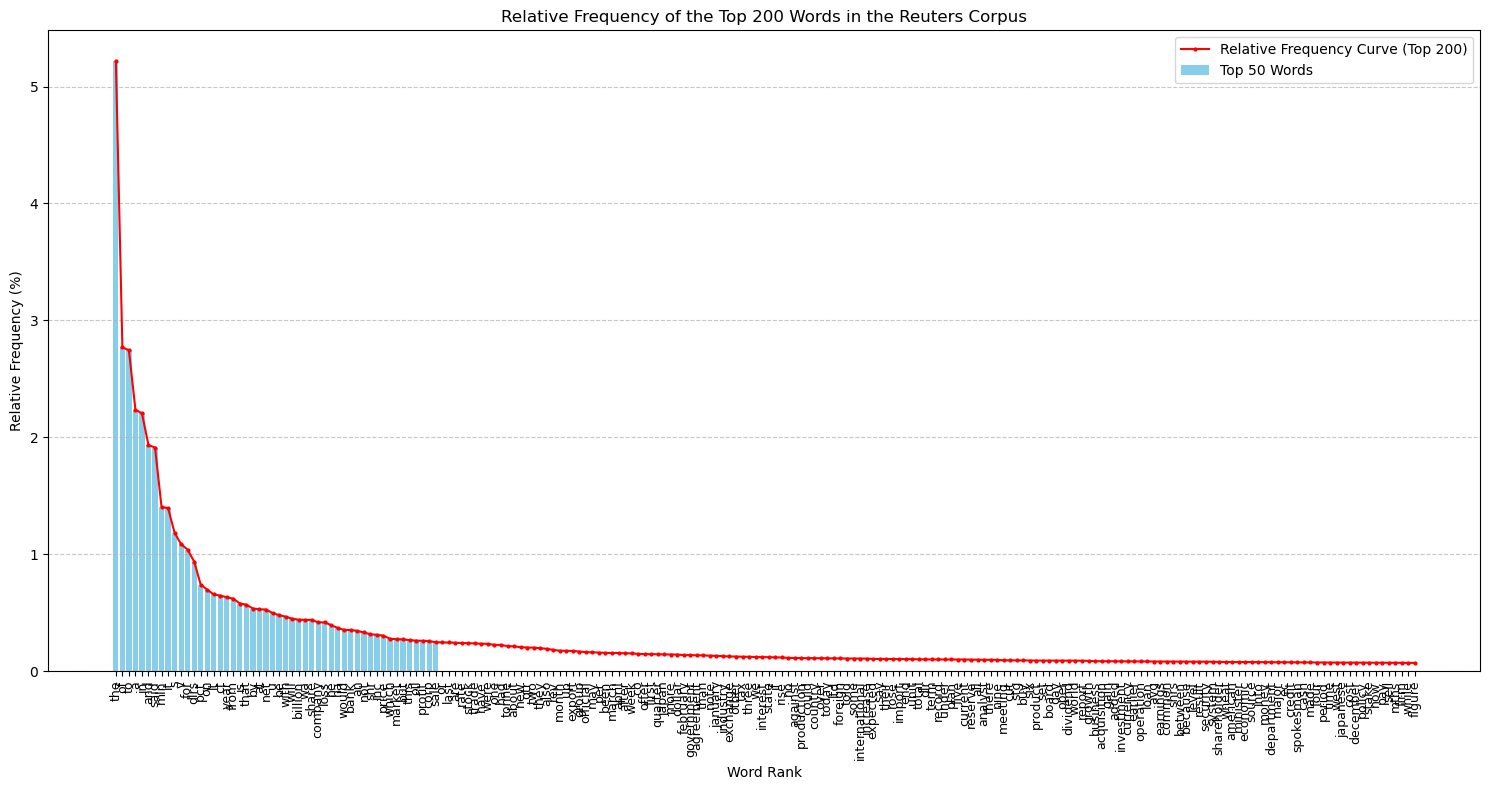

In [6]:
# Identify the 200 highest frequency words
top_200 = most_common_sorted[:200]
words, counts = zip(*top_200)

# Calculate Relative Frequency 
relative_frequencies = [(cnt / total_cleaned_count) * 100 for cnt in counts]

# Create the Visualization
plt.figure(figsize=(15, 8))

# Plotting the top 50 as a bar chart for readability and the full 200 as a line
plt.bar(words[:50], relative_frequencies[:50], color='skyblue', label='Top 50 Words')
plt.plot(words, relative_frequencies, color='red', marker='o', markersize=2, label='Relative Frequency Curve (Top 200)')

plt.xticks(rotation=90, fontsize=9)
plt.title("Relative Frequency of the Top 200 Words in the Reuters Corpus")
plt.xlabel("Word Rank")
plt.ylabel("Relative Frequency (%)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Visualization confirms the presence of Power Law distribtion in the Reuters corpus. As expected, the word "the" is the most frequent token, accounting for over 5% of the entire 1.3-million word dataset. This aligns with standard English corpora where "the" typically acts as the primary determiner. There is a precipitous drop-off between the top-ranked word and the rest of the list. By the time we reach the 50th word, the relative frequency has already fallen below 0.5%. The Top 50 is dominated by functional stop-words (of, to, and, in). However, the influence of the news domain is immediately visible with the high ranking of "said", which serves as the primary anchor for journalistic attribut

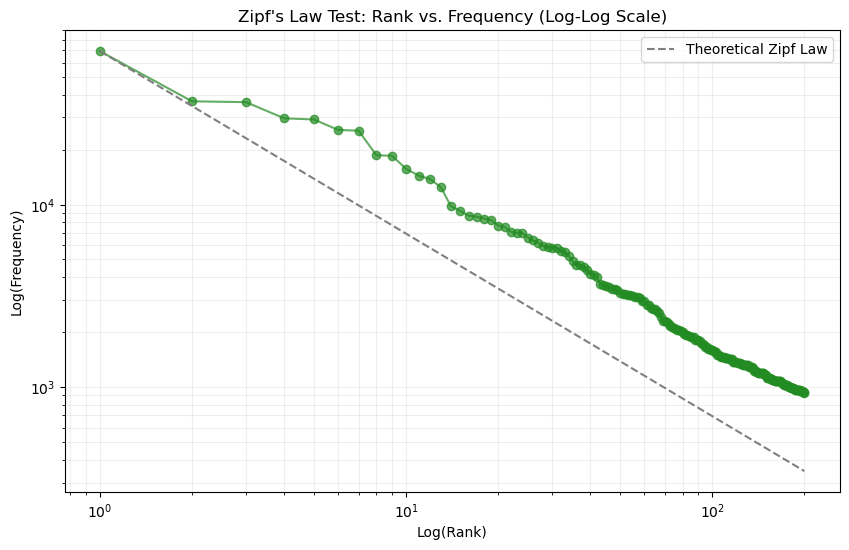

In [7]:
# Prepare data for Log-Log plot
ranks = np.arange(1, 201) # Ranks 1 to 200
frequencies = [cnt for word, cnt in top_200]

# Create the Log-Log Visualization
plt.figure(figsize=(10, 6))
plt.loglog(ranks, frequencies, marker="o", linestyle='-', color='forestgreen', alpha=0.7)

# Add a theoretical Zipf line for comparison (Freq proportional to 1/Rank)
# Scale it to match the starting frequency of our top word
zipf_theoretical = [frequencies[0] / r for r in ranks]
plt.loglog(ranks, zipf_theoretical, linestyle='--', color='gray', label='Theoretical Zipf Law')

plt.title("Zipf's Law Test: Rank vs. Frequency (Log-Log Scale)")
plt.xlabel("Log(Rank)")
plt.ylabel("Log(Frequency)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

The log-log visualization provides strong empirical evidence that the word frequencies in the Reuters corpus follow Zipf’s Law. By transforming the data to a logarithmic scale, the steep curve from the previous plot is linearized, showing a clear inverse relationship between a word's rank and its frequency. The observed frequencies (green line) descend in a nearly straight line, paralleling the theoretical Zipfian slope (dashed line). This indicates that the probability of a word occurring is approximately $1/rank$. Despite the niche nature of financial journalism, the corpus adheres remarkably well to Zipf’s Law. This proves that even when subject matter is highly constrained, the underlying statistical distribution of human language remains remarkably consistent.

While the Reuters corpus adheres to the mathematical structure of Zipf’s Law, its specific high-frequency content deviates significantly from a general English sample. The most distinct feature is the extreme density of journalistic attribution, with the word "said" ranking far higher than it would in fiction or casual speech. Additionally, the data is heavily saturated with economic tokens and abbreviations such as "mln" (million), "pct" (percent), and "dlrs" (dollars). Since the subject matter is restricted to business and politics, the vocabulary is more "efficient" and repetitive than a broader corpus, allowing a mere 96-word core to represent half of the total text volume. This reflects a specialized technical density that prioritizes clarity and standardized reporting over the narrative variety found in "all words in all corpora".